<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/04_California_Housing_Regression_Regularisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CALIFORNIA HOUSING - LINEAR REGRESSION AND REGULARISATION

1. DATASET LOADED
Dataset shape: (20640, 9)

First five rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



2. DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

3. STATISTICAL SUMMARY


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



4. CHECK MISSING VALUES
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


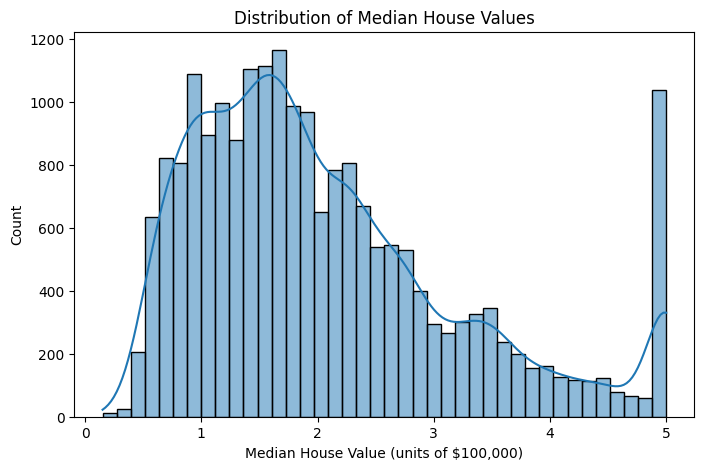

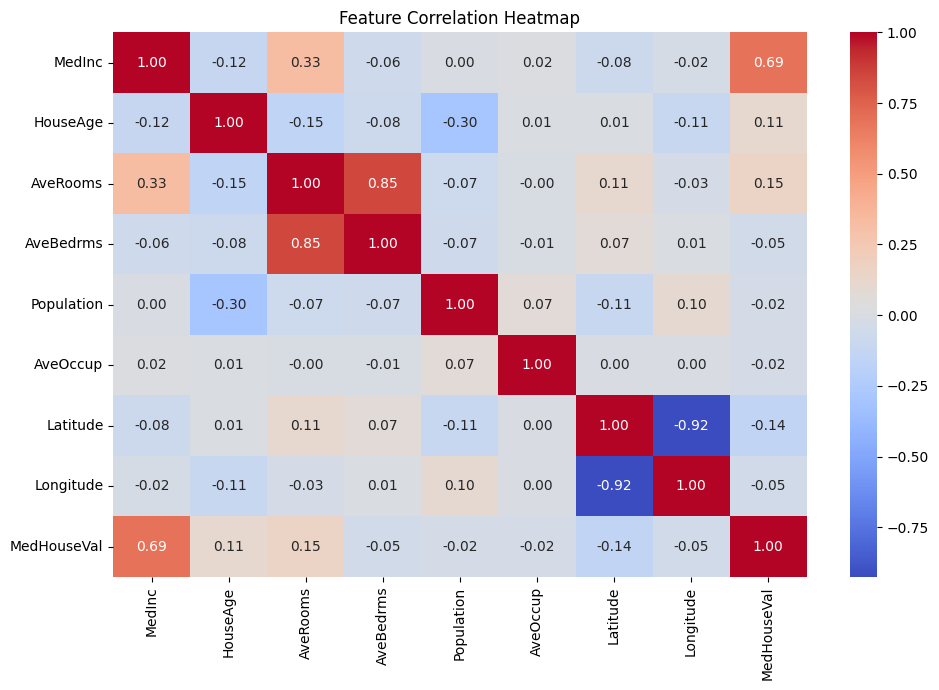


5. DATA SPLIT
Training samples: 16512
Testing samples: 4128

6. MODEL TRAINING AND EVALUATION

Linear Regression
MAE: 0.5332
RMSE: 0.7456
R2 Score: 0.5758

Ridge Regression
MAE: 0.5332
RMSE: 0.7456
R2 Score: 0.5758

Lasso Regression
MAE: 0.5353
RMSE: 0.7404
R2 Score: 0.5816

7. MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
2,Lasso Regression,0.535326,0.740442,0.581615
1,Ridge Regression,0.533193,0.745557,0.575816
0,Linear Regression,0.533200,0.745581,0.575788


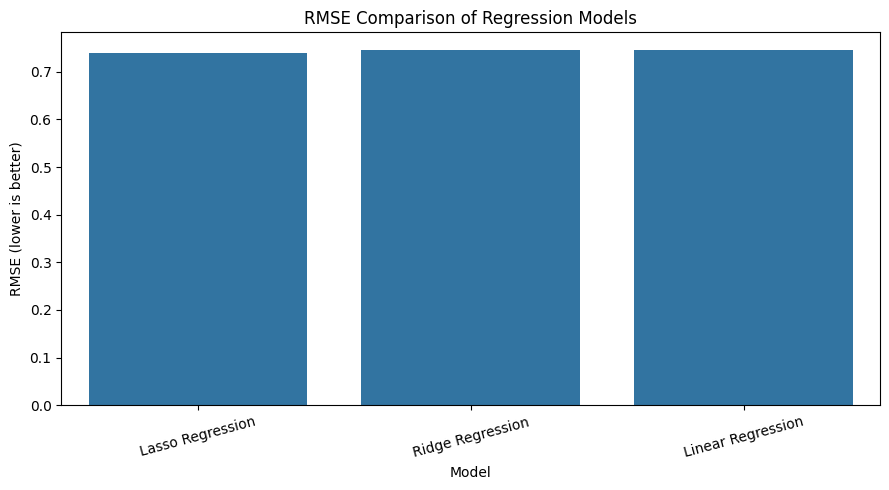

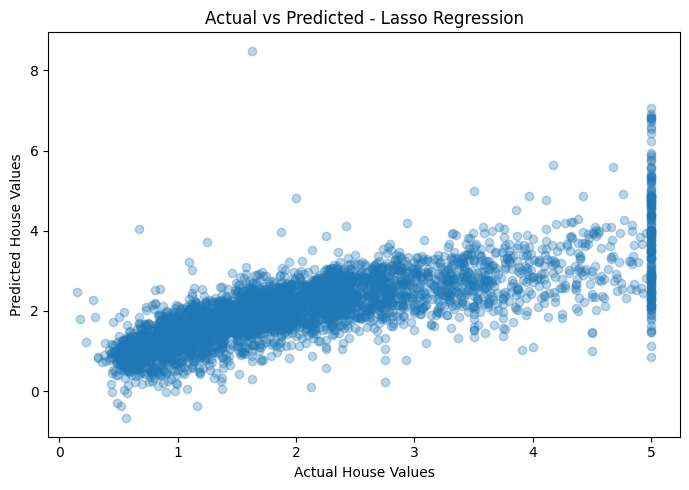


8. CONCLUSION
Linear, Ridge, and Lasso regression models were trained.
Features were standardized using training data only.
Models were compared using MAE, RMSE, and R2 score.
Best model by RMSE: Lasso Regression
Results saved to california_housing_model_comparison.csv


In [1]:

# PROGRAM 4: CALIFORNIA HOUSING - LINEAR REGRESSION AND REGULARISATION

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("CALIFORNIA HOUSING - LINEAR REGRESSION AND REGULARISATION")
print("=" * 70)

# 2. Load Dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("\n1. DATASET LOADED")
print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

print("\n2. DATASET INFORMATION")
df.info()

print("\n3. STATISTICAL SUMMARY")
display(df.describe())

# 3. Exploratory Data Analysis
print("\n4. CHECK MISSING VALUES")
print(df.isnull().sum())

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="MedHouseVal", bins=40, kde=True)
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value (units of $100,000)")
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 4. Separate Features and Target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# 5. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n5. DATA SPLIT")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 6. Define Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000)
}

results = []
predictions = {}

# 7. Train and Evaluate Models
print("\n6. MODEL TRAINING AND EVALUATION")

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"\n{name}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

# 8. Compare Results
results_df = pd.DataFrame(results).sort_values(by="RMSE")
print("\n7. MODEL COMPARISON")
display(results_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("RMSE Comparison of Regression Models")
plt.ylabel("RMSE (lower is better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 9. Actual vs Predicted Values
best_model_name = results_df.iloc[0]["Model"]
best_predictions = predictions[best_model_name]

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_predictions, alpha=0.3)
plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

# 10. Save Results
results_df.to_csv("california_housing_model_comparison.csv", index=False)

print("\n8. CONCLUSION")
print("Linear, Ridge, and Lasso regression models were trained.")
print("Features were standardized using training data only.")
print("Models were compared using MAE, RMSE, and R2 score.")
print("Best model by RMSE:", best_model_name)
print("Results saved to california_housing_model_comparison.csv")